In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())

print("\nDataset Shape:",df.shape)

print("\nMissing Values")
print(df.isnull().sum())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset Shape: (150, 4)

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [3]:

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


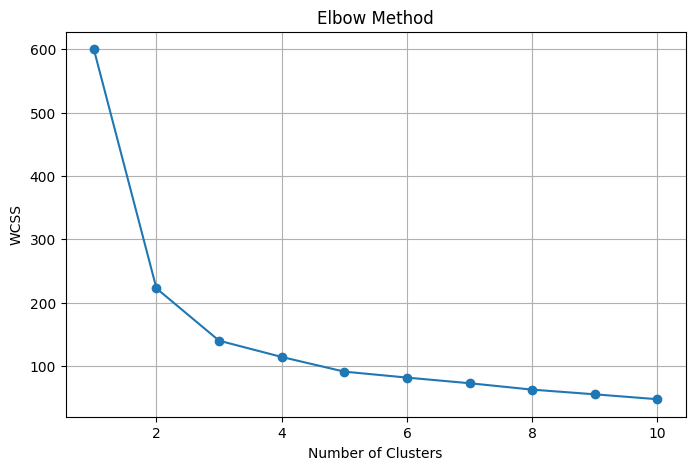

In [4]:
wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid()

plt.show()

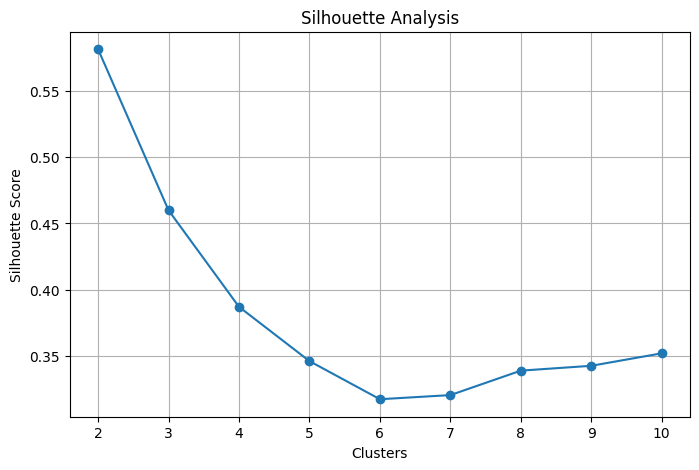

Best K = 2


In [5]:
scores=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(X)

    score=silhouette_score(X,labels)

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),scores,marker='o')

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid()

plt.show()

best_k=np.argmax(scores)+2

print("Best K =",best_k)

In [6]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels=kmeans.fit_predict(X)

df["KMeans_Cluster"]=kmeans_labels

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   KMeans_Cluster  
0               1  
1               1  
2               1  
3               1  
4               1  


In [7]:
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X)

pca_df=pd.DataFrame()

pca_df["PC1"]=X_pca[:,0]
pca_df["PC2"]=X_pca[:,1]

pca_df["Cluster"]=kmeans_labels

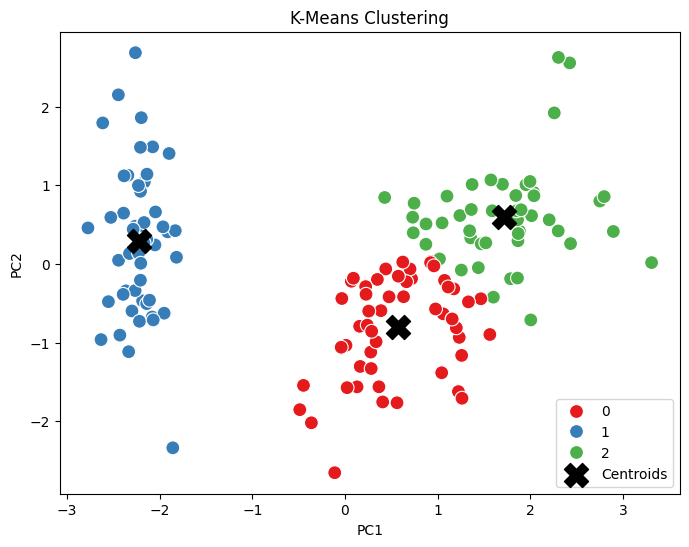

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    data=pca_df,
    s=100
)

centroids=pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering")

plt.legend()

plt.show()

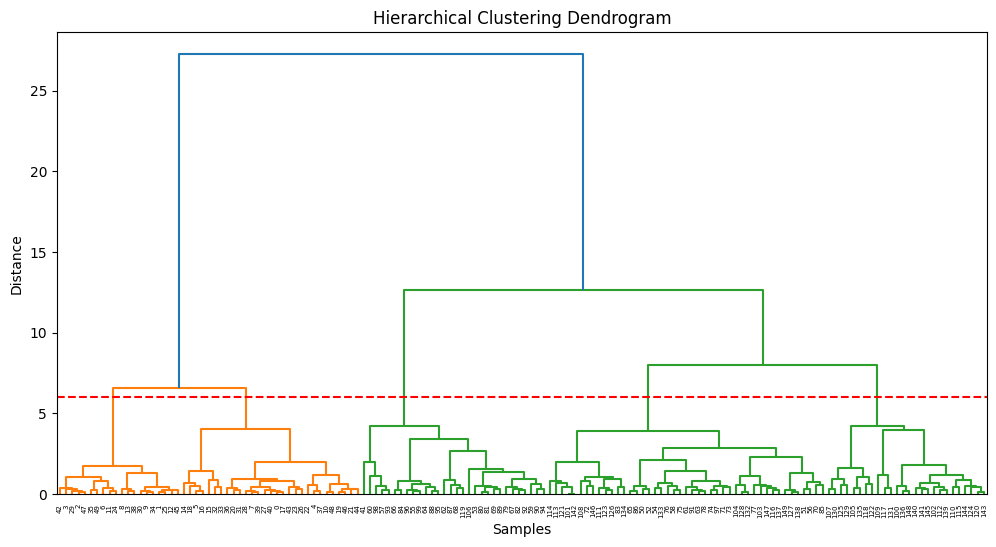

In [9]:
linked=linkage(X,method="ward")

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.axhline(
    y=6,
    color='red',
    linestyle='--'
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Samples")

plt.ylabel("Distance")

plt.show()

In [11]:
hierarchical=AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hier_labels=hierarchical.fit_predict(X)

df["Hierarchical_Cluster"]=hier_labels

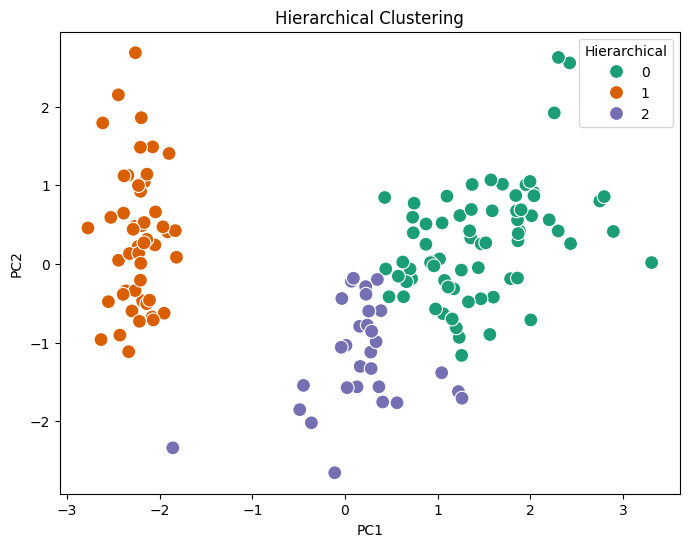

In [12]:
pca_df["Hierarchical"]=hier_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Hierarchical",
    palette="Dark2",
    data=pca_df,
    s=100
)

plt.title("Hierarchical Clustering")

plt.show()

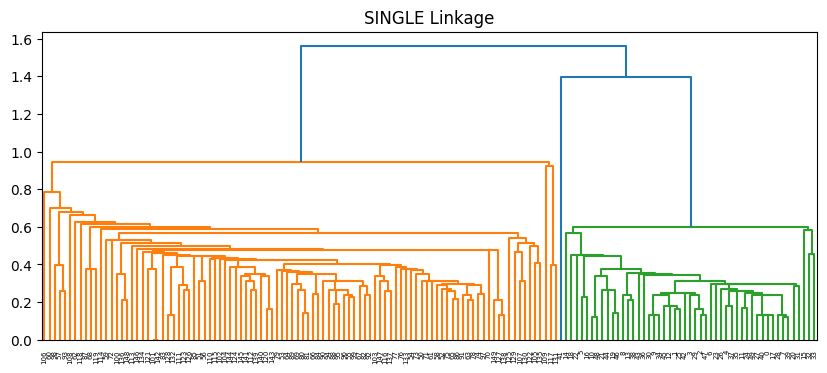

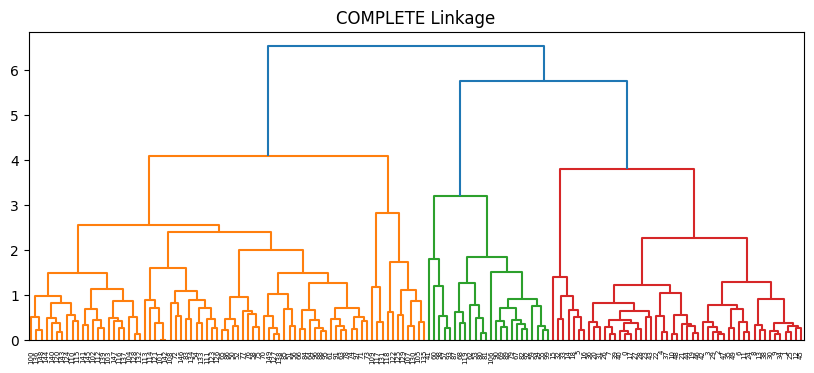

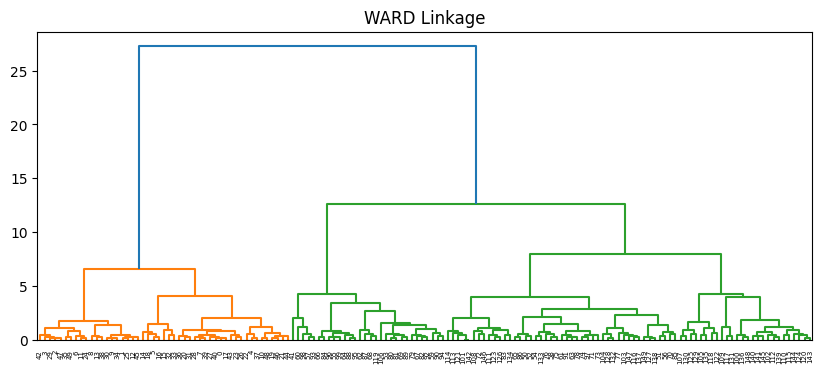

In [13]:
methods=["single","complete","ward"]

for method in methods:

    plt.figure(figsize=(10,4))

    linked=linkage(X,method=method)

    dendrogram(linked)

    plt.title(f"{method.upper()} Linkage")

    plt.show()

In [14]:
kmeans_score=silhouette_score(
    X,
    kmeans_labels
)

hier_score=silhouette_score(
    X,
    hier_labels
)

print("KMeans Silhouette :",round(kmeans_score,3))

print("Hierarchical Silhouette :",round(hier_score,3))

KMeans Silhouette : 0.46
Hierarchical Silhouette : 0.447


In [15]:
comparison=pd.DataFrame({

    "Algorithm":[
        "K-Means",
        "Hierarchical"
    ],

    "Clusters":[
        3,
        3
    ],

    "Silhouette Score":[
        kmeans_score,
        hier_score
    ]

})

comparison

,Algorithm,Clusters,Silhouette Score
0,K-Means,3,0.459948
1,Hierarchical,3,0.446689
